## Diagrams to Illustrate Scrolling

In [15]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:70% !important; }</style>"))

In [16]:
!mkdir -p scrolling

### Draw the Scroll Segments

In [6]:
from PIL import Image, ImageDraw, ImageFont

for level in range(1,16):
    fore_img = Image.open(f"surfaces_raw/{level}_full.png")
    img = Image.new('RGBA', (fore_img.width , 30 + fore_img.height + 90))
    img.paste(fore_img, (0, 30))

    draw = ImageDraw.Draw(img)
    SEGMENT_WIDTH = 32 * 8
    clip_start = 0
    clip_end = SEGMENT_WIDTH
    for i in range(0,16):
        draw.rectangle([(clip_start,0),(clip_start,img.height-1)], 
                       fill=None, outline=(0,0,0,255), width=2)
        
        label_text = ("0"+str(i))[-2:]
        label_fnt = ImageFont.truetype("Eurostile.ttf", 52)
        label_x = int(clip_start + ((clip_end - clip_start) / 2) + -40)
        label_y = 30 + fore_img.height + 30
        draw.text((label_x, label_y), label_text, font=label_fnt, fill="black")

        clip_start += SEGMENT_WIDTH
        clip_end += SEGMENT_WIDTH
    
    img.save(f"scrolling/segments/{level}_scroll_segments.png")

    clip_start = 0
    for i in range(0,16):
        seg_img = img.copy()
        draw = ImageDraw.Draw(seg_img)
        draw.rectangle([(clip_start,0),(clip_start + SEGMENT_WIDTH, seg_img.height-1)], 
                       fill=None, outline="red", width=4)

        pixels = seg_img.load()
        for x in range(0, clip_start):
            for y in range(0, seg_img.height):
                alpha = int((pixels[x, y][3] / 5) * 3)
                pixels[x,y] = pixels[x, y][:3] + (alpha,)

        clip_start += SEGMENT_WIDTH
        for x in range(clip_start, seg_img.width):
            for y in range(0, seg_img.height):
                alpha = int((pixels[x, y][3] / 5) * 3)
                pixels[x,y] = pixels[x, y][:3] + (alpha,)

        seg_img.save(f"scrolling/segments/{level}_scroll_segments_{i}_selected.png")
    
    img

KeyboardInterrupt: 

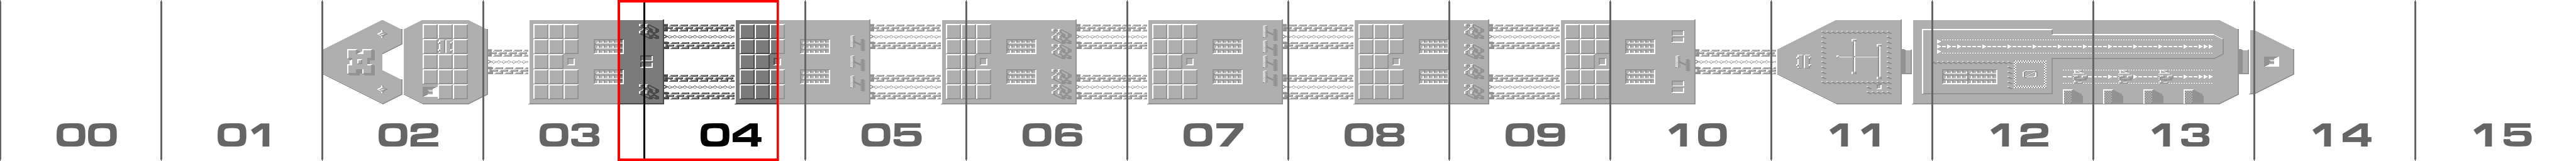

In [7]:
from PIL import Image, ImageDraw, ImageFont
level = 10
SEGMENT = 3
XPOS = 214
seg_img = Image.open(f"scrolling/segments/{level}_scroll_segments.png")

clip_start = (SEGMENT_WIDTH * SEGMENT) + XPOS
draw = ImageDraw.Draw(seg_img)
draw.rectangle([(clip_start,0),(clip_start + SEGMENT_WIDTH, seg_img.height-1)], 
               fill=None, outline="red", width=4)

pixels = seg_img.load()
for x in range(0, clip_start):
    for y in range(0, seg_img.height):
        alpha = int((pixels[x, y][3] / 5) * 3)
        pixels[x,y] = pixels[x, y][:3] + (alpha,)

clip_start += SEGMENT_WIDTH
for x in range(clip_start, seg_img.width):
    for y in range(0, seg_img.height):
        alpha = int((pixels[x, y][3] / 5) * 3)
        pixels[x,y] = pixels[x, y][:3] + (alpha,)

seg_img.save(f"scrolling/{level}_scroll_segments_{SEGMENT}_selected_{XPOS}.png")
seg_img


### Draw Scroll Segments with Memory Addresses

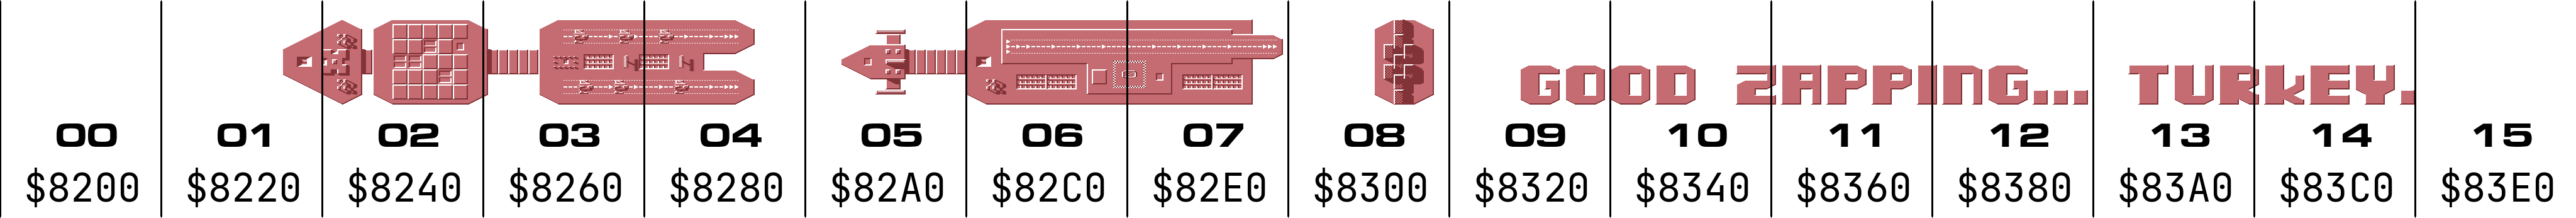

In [64]:
from PIL import Image, ImageDraw, ImageFont

for level in range(1,16):
    fore_img = Image.open(f"surfaces_raw/{level}_full.png")
    img = Image.new('RGBA', (fore_img.width , 30 + fore_img.height + 180))
    img.paste(fore_img, (0, 30))

    draw = ImageDraw.Draw(img)
    SEGMENT_WIDTH = 32 * 8
    clip_start = 0
    clip_end = SEGMENT_WIDTH
    ADDR = 0x8200
    for i in range(0,16):
        draw.rectangle([(clip_start,0),(clip_start,img.height-1)], 
                       fill=None, outline=(0,0,0,255), width=2)

        label_text = ("0"+str(i))[-2:]
        label_fnt = ImageFont.truetype("Eurostile.ttf", 52)
        label_x = int(clip_start + ((clip_end - clip_start) / 2) + -40)
        label_y = 30 + fore_img.height + 30
        draw.text((label_x, label_y), label_text, font=label_fnt, fill="black")

        label_text = "$"+hex(ADDR)[2:].upper()
        label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", 62)
        label_x = int(clip_start + ((clip_end - clip_start) / 2) + -90)
        label_y = 90 + fore_img.height + 30
        draw.text((label_x, label_y), label_text, font=label_fnt, fill="black")
        ADDR += 0x20
        
        clip_start += SEGMENT_WIDTH
        clip_end += SEGMENT_WIDTH
    
    img.save(f"scrolling/segments/{level}_scroll_segments_addresses.png")

img

### Draw A Scroll Segment with a Grid

In [18]:
!mkdir -p scrolling/surface_diagrams

In [19]:
def getDreadnoughtData(level_data_lines):
    raw_dreadnought_data = [l[14:].strip() for l in level_data_lines]
    dreadnought_data = [x for l in raw_dreadnought_data for x in l.split(',')]

    end_of_base_data = dreadnought_data.index('$00')
    base_data = [x[1:] for x in dreadnought_data[:end_of_base_data]]
    raw_location_data = dreadnought_data[end_of_base_data+1:]
    location_data = []
    for i in range(0, len(raw_location_data), 3):
        hi_byte = int(raw_location_data[i][1:],16)
        if not hi_byte:
            break
        hi_byte |= 0x80
        hi_byte &= 0xBF
        hi_byte = hex(hi_byte)[2:]
        lo_byte = raw_location_data[i+1][1:]
        hex_location = hi_byte + lo_byte
        location = int(hex_location,16)
        structure = raw_location_data[i+2][1:]
        location_data += [(hex_location, location,structure)]
    dreadnought_surface = (base_data,location_data)
    return dreadnought_surface

# Read in bulk of the dreadnought data from level data first.
level_data_file = "uridium/src/level_data.asm"
lines_in_file = open(level_data_file,'r').readlines()

dreadnought_surfaces = {}
level_data_lines = []
current_dreadnought = ""
for l in lines_in_file:
    if l.startswith("level") and "DreadnoughtData" in l:
        if current_dreadnought:
            dreadnought_surfaces[current_dreadnought] = getDreadnoughtData(level_data_lines)
        current_dreadnought = l[:22].strip()
        level_data_lines = []
    if ".BYTE" not in l:
        continue
    level_data_lines += [l]
dreadnought_surfaces[current_dreadnought] = getDreadnoughtData(level_data_lines)

# Read in remaining dreadnoughts from charset.asm
level_data_file = "uridium/src/charset.asm"
lines_in_file = open(level_data_file,'r').readlines()

assert "level7DreadnoughtData" in lines_in_file[1297]
level_data_lines = [l for l in lines_in_file[1298:1358] if ".BYTE" in l]
dreadnought_surfaces["level7DreadnoughtData"] = getDreadnoughtData(level_data_lines)

assert "level8DreadnoughtData" in lines_in_file[1358]
level_data_lines = [l for l in lines_in_file[1359:1425] if ".BYTE" in l]
dreadnought_surfaces["level8DreadnoughtData"] = getDreadnoughtData(level_data_lines)


In [20]:
import math
test_image = Image.open(f"surface_character_set_diagrams/character_sets/1_00.png")
character_height = test_image.height
character_width = test_image.width

DREADNOUGHT_COLS = 0x200
LOCATION_START = 0x8200
LOCATION_END = 0xA400

width = DREADNOUGHT_COLS * character_width # padding from diagram
height = int((LOCATION_END - LOCATION_START) / DREADNOUGHT_COLS) * character_height # 128

for LEVEL in range(1,16):
    base_data, location_data = dreadnought_surfaces[f"level{LEVEL}DreadnoughtData"]
    img = Image.new( 'RGBA', (width,height))

    x,y = 64 * character_width,0
    for structure in base_data:
        strip_image = Image.open(f"surface_character_set_diagrams/surface_strips_hex/{LEVEL}_{structure}_no_text.png")
        # Y position is relative to the bottom of the map.
        y = height - strip_image.height
        img.paste(strip_image,(x,y),mask=strip_image)
        
        x+= strip_image.width

    for hex_offset, location, structure in location_data:
        if structure == "20":
            print(structure)
        strip_image = Image.open(f"surface_character_set_diagrams/surface_structures_hex/{LEVEL}_{structure}_no_text.png")
        
        offset = location - LOCATION_START
        x = (offset % DREADNOUGHT_COLS) * character_width

        # The location given is for the bottom of the object (uridium draws upwards)
        y = (int(math.ceil(offset / DREADNOUGHT_COLS)) * character_height) - (strip_image.height) # padding at bottom of diagram
        img.paste(strip_image,(x,y),mask=strip_image)

    img.save(f"scrolling/surface_diagrams/{LEVEL}_no_text.png")


In [78]:
from PIL import Image, ImageDraw, ImageColor, ImageFont
def generateSurfaceDiagramWithGrid(level_name, level_number, level_image, description, X_START, X_END):
    img = Image.new('RGBA', (50 + level_image.width + 140, 230 + level_image.height + 20))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Sprite label
    #label_text = f"URIDIUM/{('00'+str(level_number))[-2:]}/{level_name}/{description}"
    label_text = f"{level_name}/{description}"
    label_fnt_size = 88
    label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size + 10
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    img.paste(txt, (140, 5))

    # Grid Literals - Rows
    grid_literals = []
    for n in range(0x82, 0xA4, 2):
        grid_literals += [hex(n)[2:].upper()]
    label_text = '\n'.join(grid_literals)
    label_fnt_size = 113
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_height = len(label_text) * label_fnt_size
    txt_width =  (label_fnt_size + 25)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="gray")
    label = txt
    img.paste(label, (10,80),mask=label)

    # Grid Literals - Cols
    grid_literals = []
    for n in range(X_START, X_END, 1):
        grid_literals += [hex(n)[2:].upper()]
    label_fnt_size = 113
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    x = 150
    for label_text in grid_literals:
        txt_height = (label_fnt_size + 25)
        txt_width =  len(label_text) * label_fnt_size
        txt = Image.new('RGBA', (txt_width, txt_height))
        draw = ImageDraw.Draw(txt)
        draw.rectangle([(0,0), txt.size], fill = "white")
        draw.text((0, 0), label_text, font=label_fnt, fill="gray")
        label = txt.rotate(90,expand=1)
        img.paste(label,(x,(img.height - label.height)),mask=label)
        x += 120

    # Main Sprite image
    img.paste(level_image, (160,100),mask=level_image)

    return img


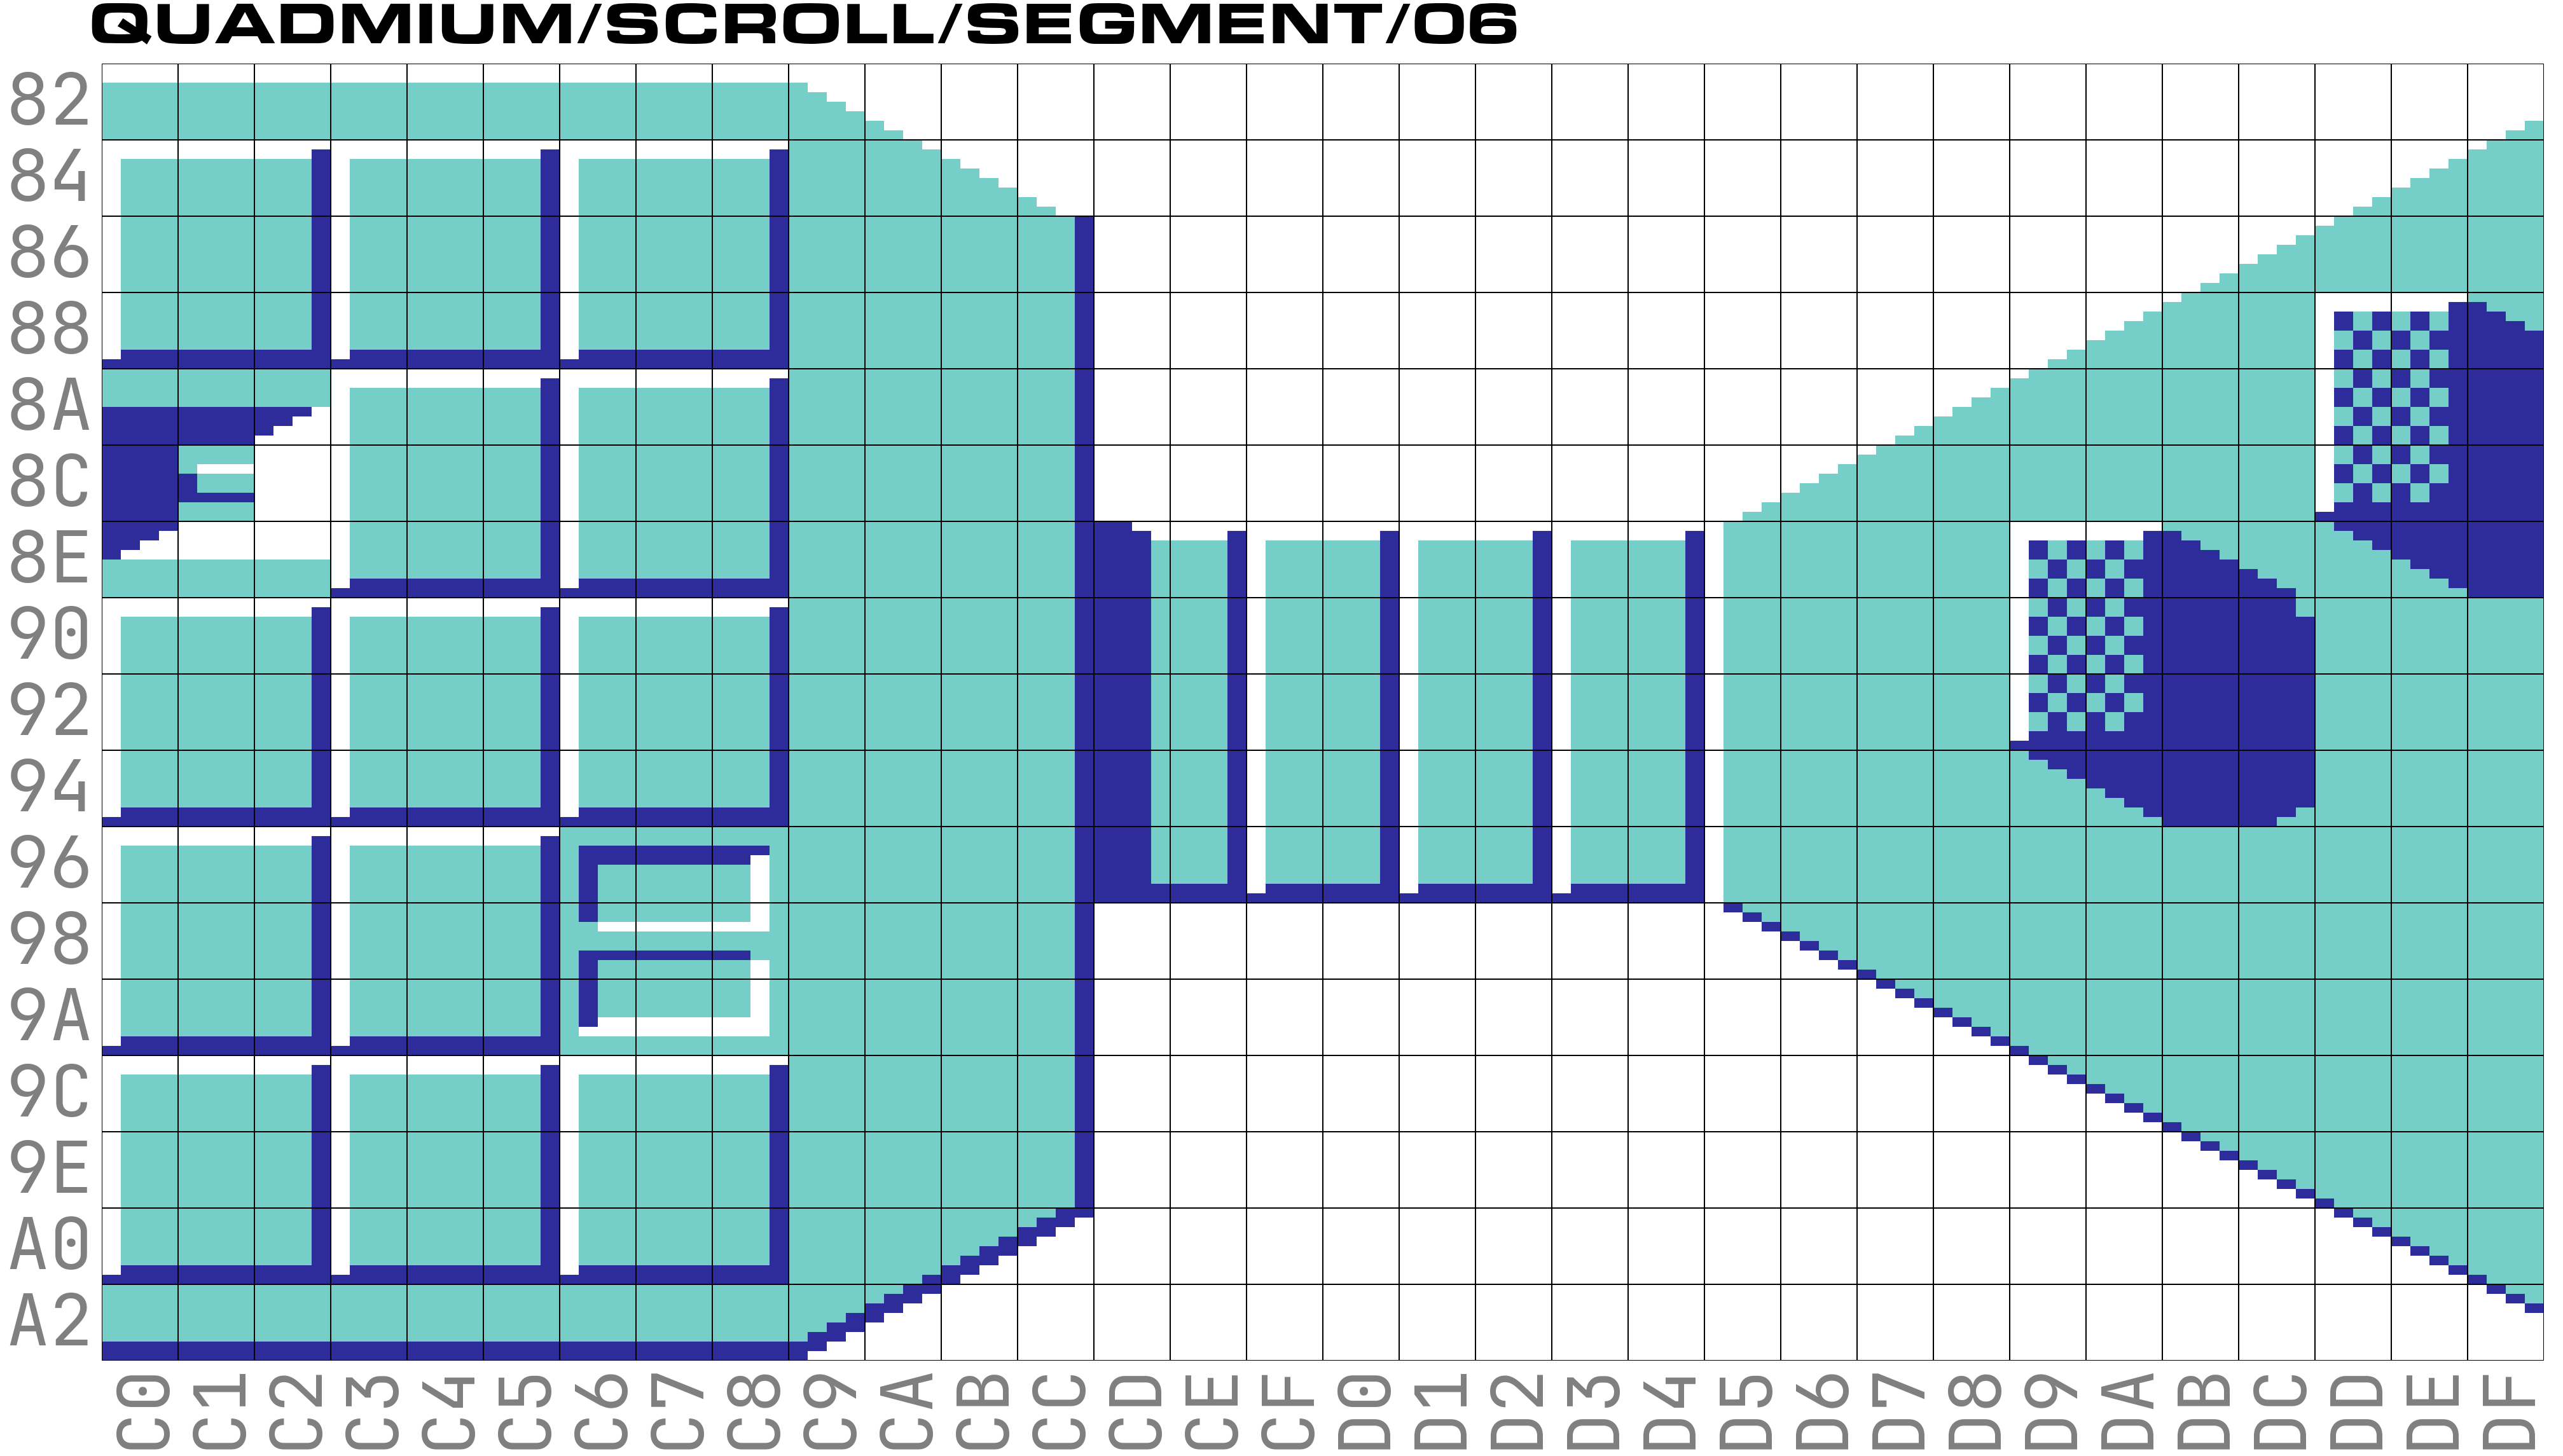

In [250]:
from PIL import Image
half_width = 11040
LEVEL = 12
SEGMENT = 6
X_START = 0x20 * SEGMENT
X_END = 0x20 * (SEGMENT+1)
crop_start = X_START * 8 * 15
crop_end = X_END * 8 * 15

img = Image.open(f"scrolling/surface_diagrams/{LEVEL}_no_text.png")
img1 = img.crop((crop_start, 0, crop_end, img.height))
img1 = generateSurfaceDiagramWithGrid("QUADMIUM", LEVEL, img1, f"SCROLL/SEGMENT/{str(SEGMENT).zfill(2)}", X_START, X_END)
img1.save(f"scrolling/{LEVEL}_segment_{SEGMENT}.png")
img1

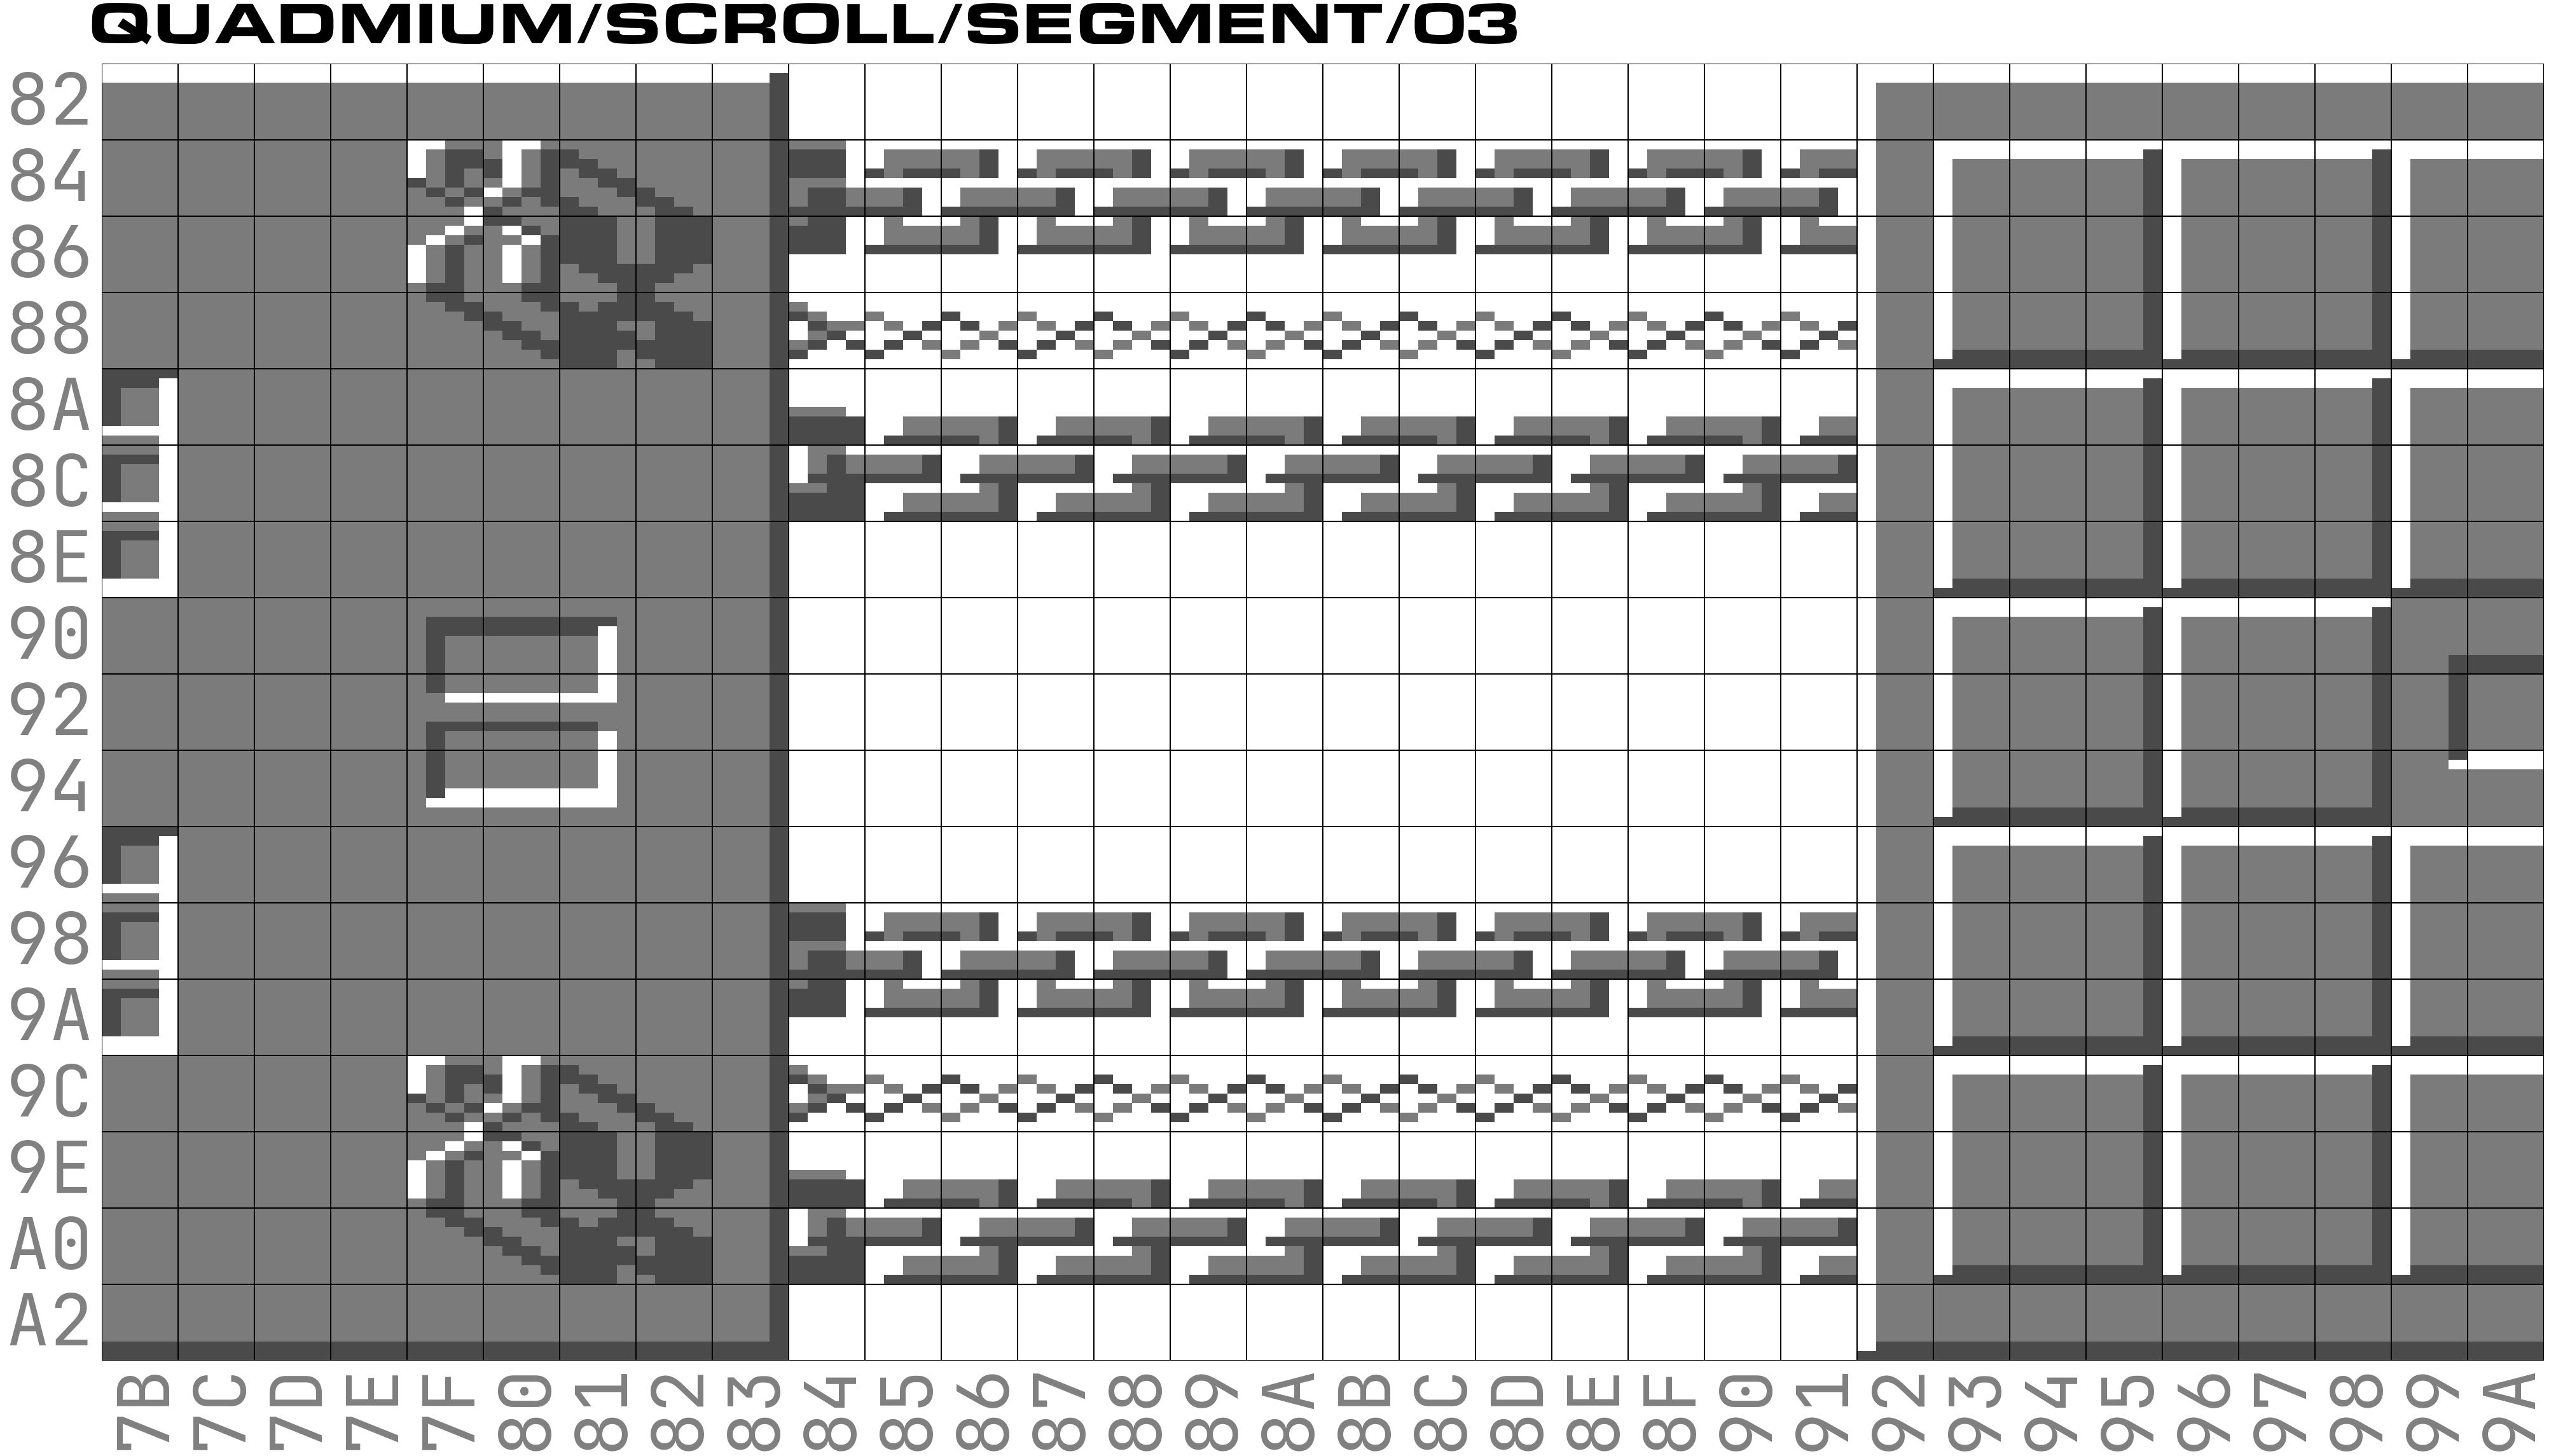

In [80]:
from PIL import Image
half_width = 11040
LEVEL = 10
SEGMENT = 3
X_OFFSET = 27
X_START = (0x20 * SEGMENT) + X_OFFSET
X_END = (0x20 * (SEGMENT+1)) + X_OFFSET
crop_start = X_START * 8 * 15
crop_end = X_END * 8 * 15

img = Image.open(f"scrolling/surface_diagrams/{LEVEL}_no_text.png")
img1 = img.crop((crop_start, 0, crop_end, img.height))
img1 = generateSurfaceDiagramWithGrid("QUADMIUM", LEVEL, img1, f"SCROLL/SEGMENT/{str(SEGMENT).zfill(2)}", X_START, X_END)
img1.save(f"scrolling/{LEVEL}_segment_{SEGMENT}_{X_OFFSET}.png")
img1

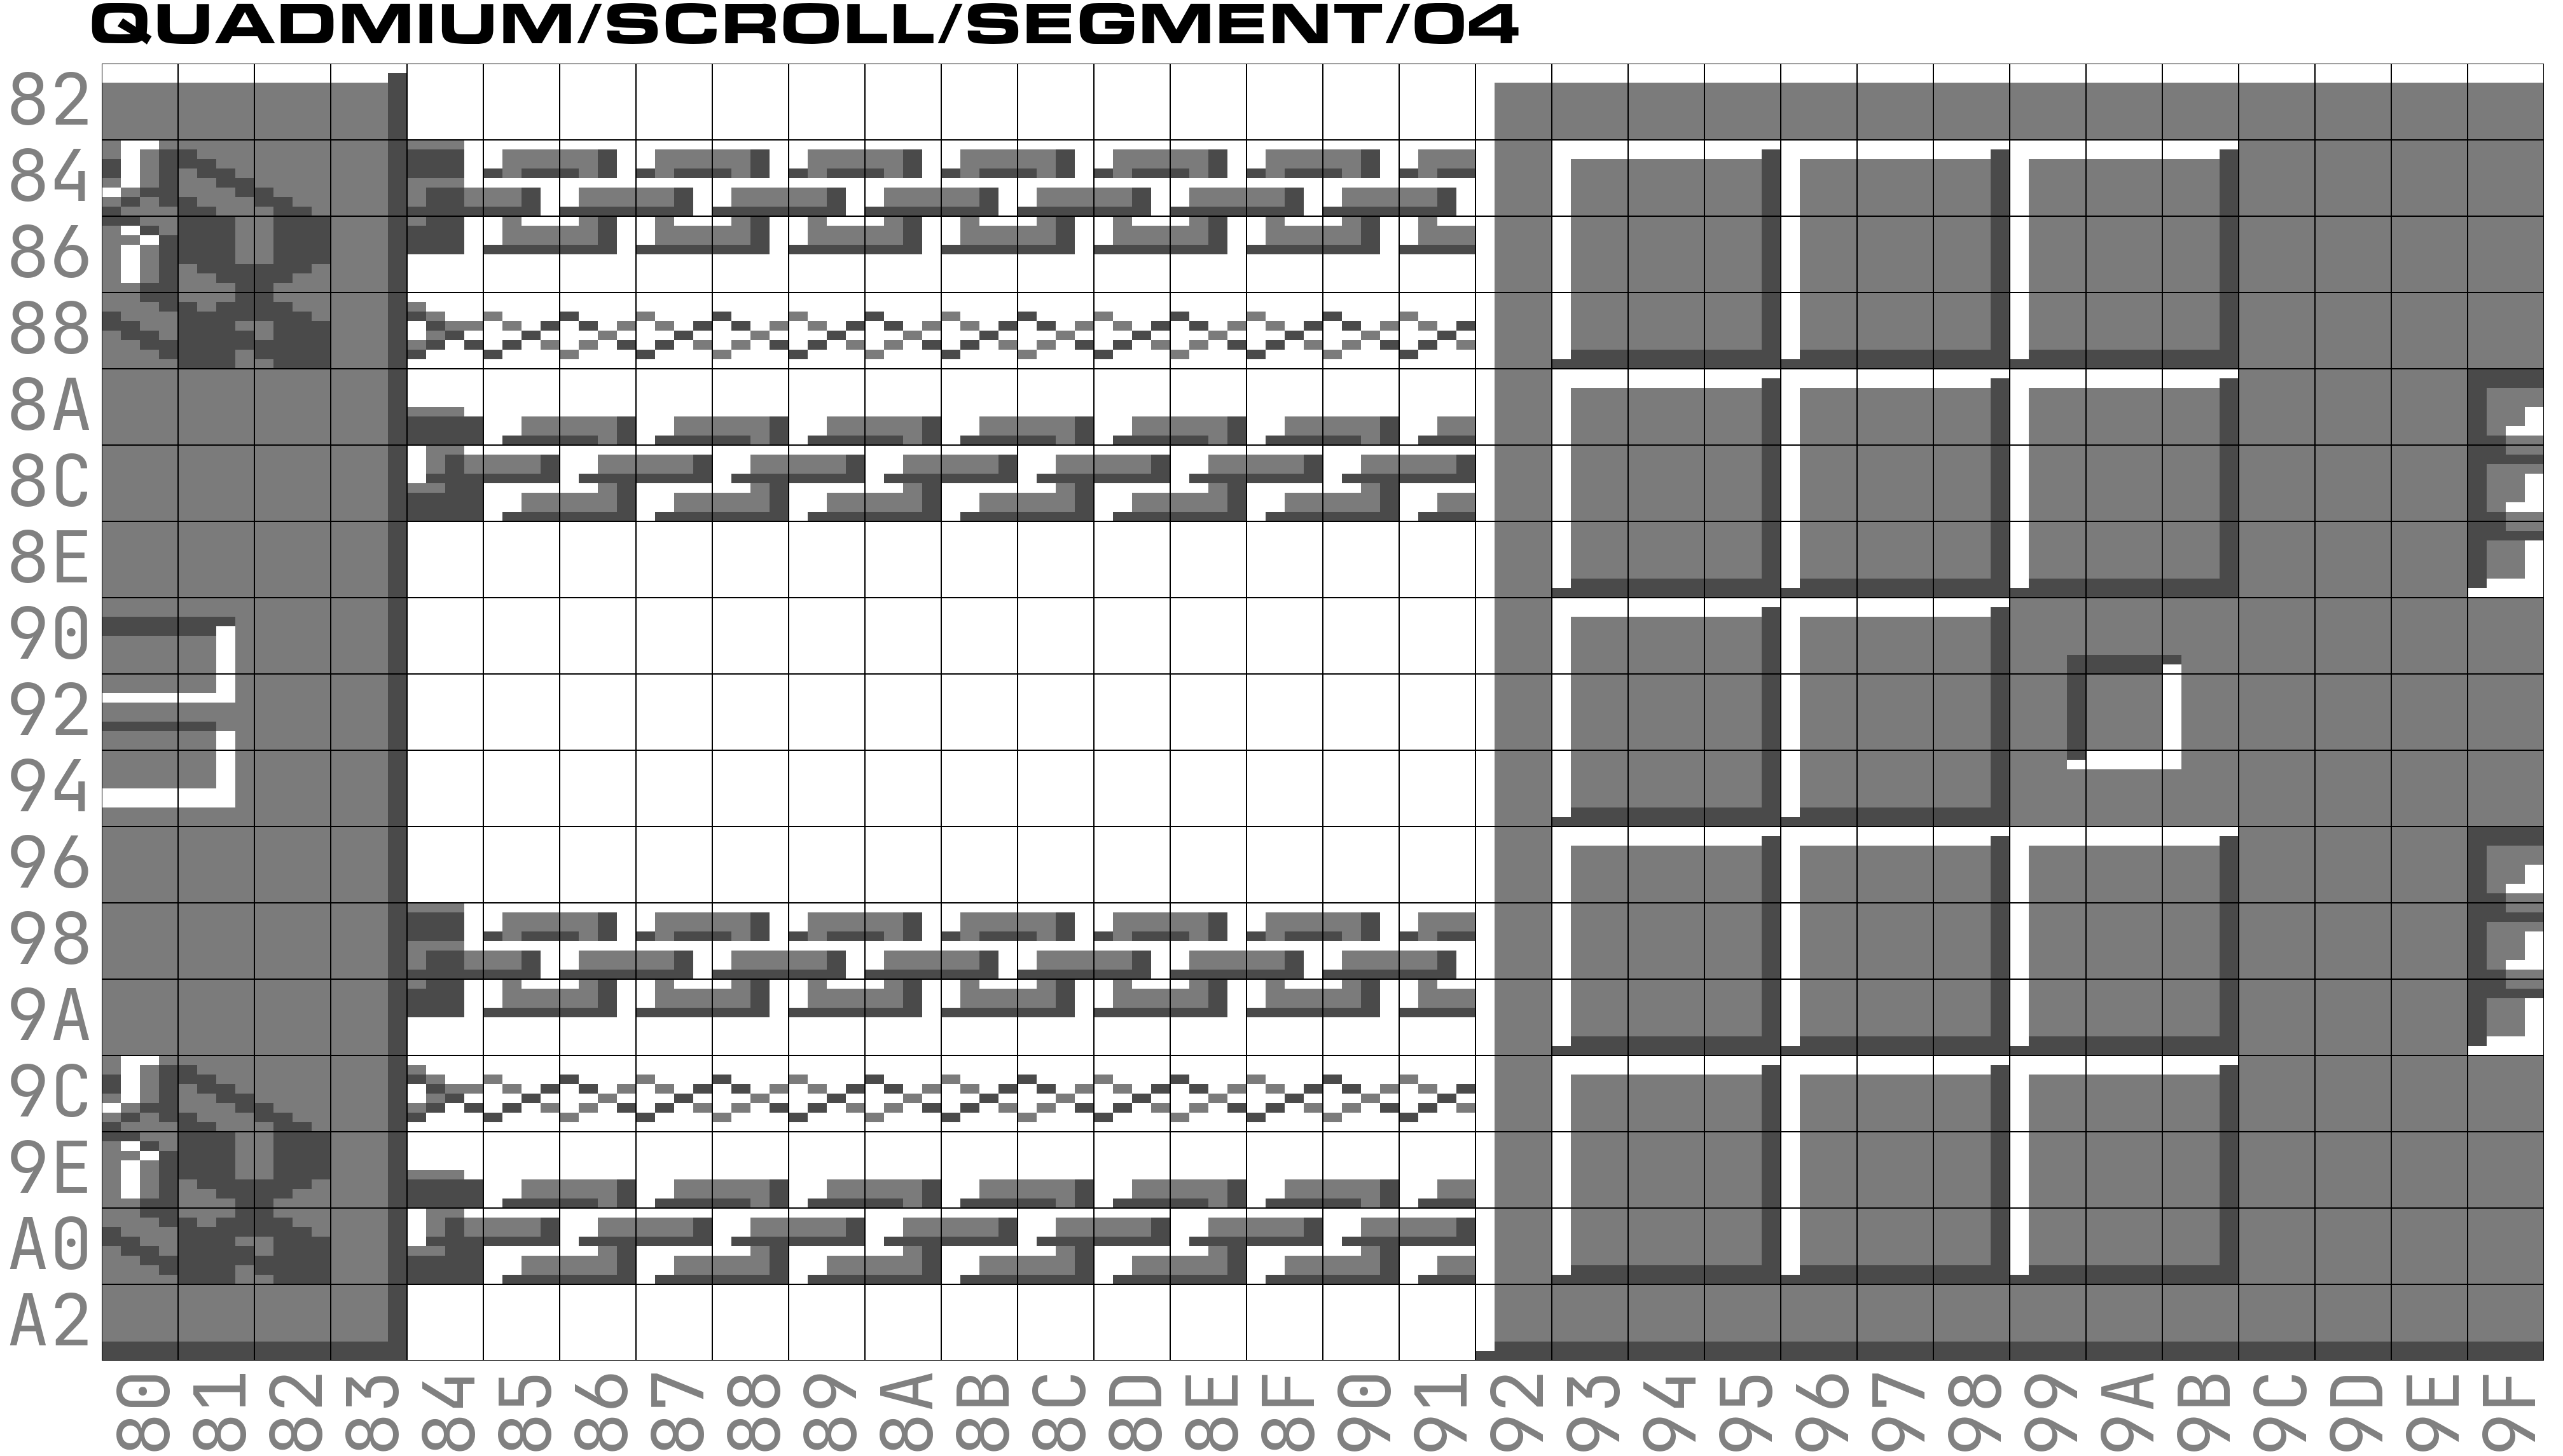

In [88]:
from PIL import Image
half_width = 11040
LEVEL = 10
SEGMENT = 4
X_OFFSET = 0
X_START = (0x20 * SEGMENT) + X_OFFSET
X_END = (0x20 * (SEGMENT+1)) + X_OFFSET
crop_start = X_START * 8 * 15
crop_end = X_END * 8 * 15

img = Image.open(f"scrolling/surface_diagrams/{LEVEL}_no_text.png")
img1 = img.crop((crop_start, 0, crop_end, img.height))
img1 = generateSurfaceDiagramWithGrid("QUADMIUM", LEVEL, img1, f"SCROLL/SEGMENT/{str(SEGMENT).zfill(2)}", X_START, X_END)
img1.save(f"scrolling/{LEVEL}_segment_{SEGMENT}_{X_OFFSET}.png")
img1

### Draw a dial for the number of pixels in the screen

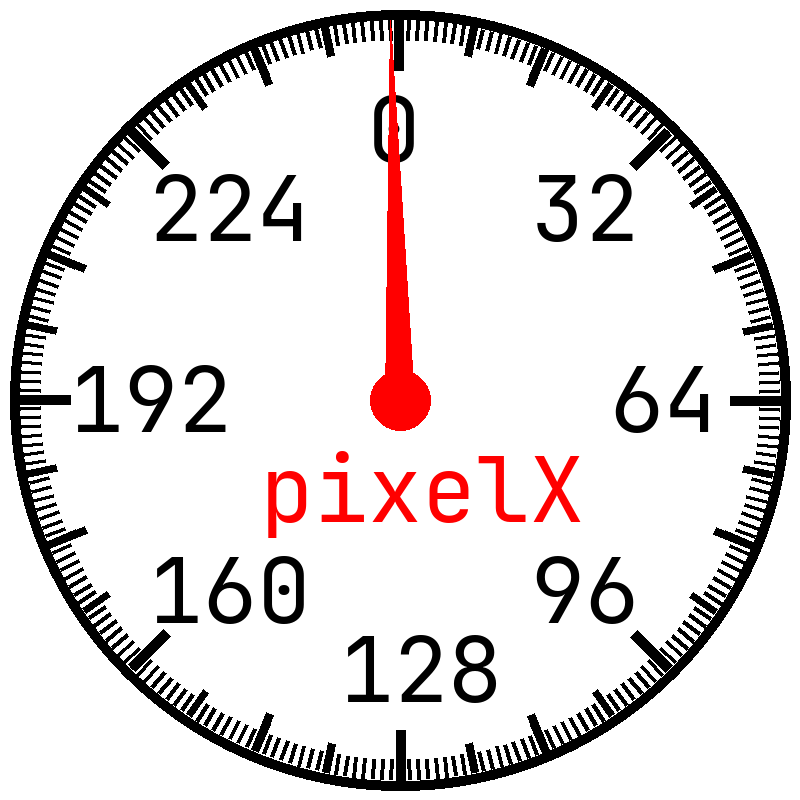

In [385]:
from math import cos, sin, radians

def draw_pixel_dial(current_value):
    width, height = 800, 800
    CENTRE = int(width/2)
    to_degree = lambda x: (d * (x/256))

    def draw_dial(draw, val, end=380):
        val = val - 64
        angle = to_degree(val)
        cosang, sinang = cos(radians(angle)), sin(radians(angle))
        x_end = CENTRE + end * cosang
        y_end = CENTRE + end * sinang

        val = 256 - val
        angle = to_degree(val)
        cosang, sinang = cos(radians(angle)), sin(radians(angle))
        
        # Retrieve vertices of the line
        x1, y1 = CENTRE, CENTRE + 15
        x2, y2 = CENTRE, CENTRE - 15
        cx = (x2 - x1) / 2 + x1
        cy = (y2 - y1) / 2 + y1

        # Rotate each around whole polyline's center point
        tx1, ty1 = x1-cx, y1-cy
        p1x = ( tx1*cosang + ty1*sinang) + cx
        p1y = (-tx1*sinang + ty1*cosang) + cy
        tx2, ty2 = x2-cx, y2-cy
        p2x = ( tx2*cosang + ty2*sinang) + cx
        p2y = (-tx2*sinang + ty2*cosang) + cy

        draw.polygon([(p1x, p1y), (x_end,y_end), (p2x, p2y)], fill = "red")
        
    def draw_markings(draw, interval=32, start=0, end=0, width=3):
        for v in range(0, 256, interval):
            angle = to_degree(v)
            x_start = CENTRE + start * cos(radians(angle))
            y_start = CENTRE + start * sin(radians(angle))
            x_end = CENTRE + end * cos(radians(angle))
            y_end = CENTRE + end * sin(radians(angle))
            draw.line((x_start, y_start, x_end, y_end), fill="black", width=width)

    img = Image.new("RGBA", (width, height), color=(255, 255, 255))  # White background
    draw = ImageDraw.Draw(img)

    # Draw the outer circle
    draw.ellipse((10, 10, width-10, height-10), outline="black", width=10)

    # Draw markings
    draw_markings(draw, interval=32, start=330, end=380, width=10)
    draw_markings(draw, interval=16, start=340, end=380, width=8)
    draw_markings(draw, interval=8, start=350, end=380, width=8)
    draw_markings(draw, interval=1, start=360, end=380, width=4)

    label_fnt_size = 90
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)

    for v in range(0, 256, 32):
        angle = to_degree(v)
        angle -= 90
        x_text = (CENTRE - 60) + 270 * cos(radians(angle))
        y_text = (CENTRE - 60) + 270 * sin(radians(angle))
        s = "\u202f0 " if v == 0 else str(v)
        draw.text((x_text, y_text), s, fill="black", font=label_fnt)

    label_fnt_size = 90
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    draw.text((CENTRE - 140, CENTRE+30), "pixelX", fill="red", font=label_fnt)

    # Draw the dial
    draw_dial(draw, current_value)
    # Draw dial handle
    draw.ellipse((CENTRE-30, CENTRE-30, CENTRE+30, CENTRE+30), fill="red")

    return img
draw_pixel_dial(255)

In [251]:
!mkdir -p scrolling/dials

In [386]:
for i in range(0,256):
    pixel_dial = draw_pixel_dial(i)
    pixel_dial.save(f"scrolling/dials/pixel_dial_{i}.png")

In [387]:
!cp scrolling/dials/* ../src/scrolling/dials/

### Draw a dial for the number of scroll segments

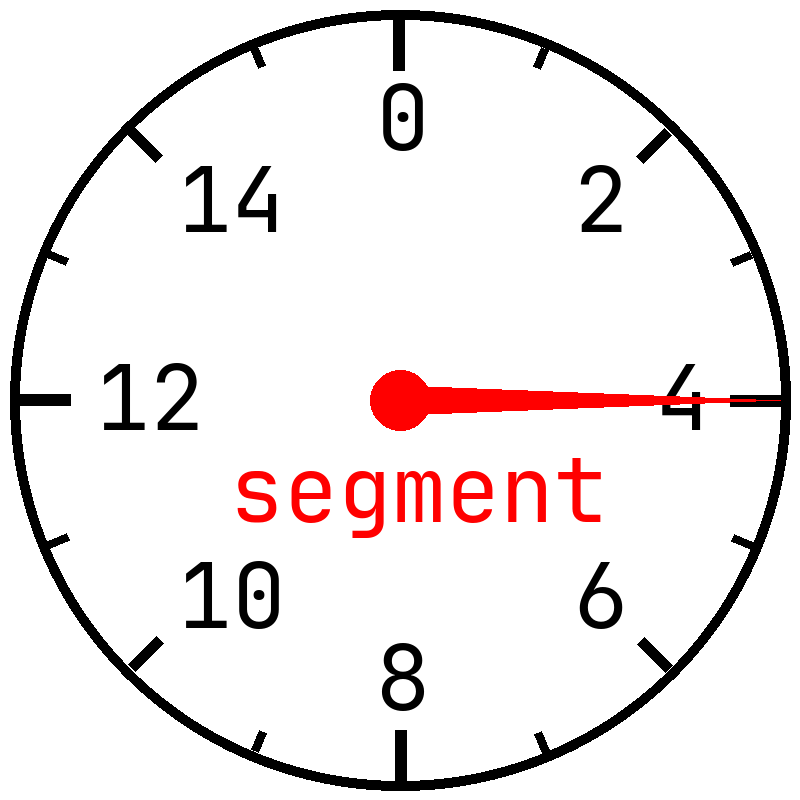

In [14]:
from math import cos, sin, radians

def draw_segment_dial(current_value):
    width, height = 800, 800
    CENTRE = int(width/2)
    to_degree = lambda x: (360 * (x/16))

    def draw_dial(draw, val, end=380):
        val = val - 4
        angle = to_degree(val)
        cosang, sinang = cos(radians(angle)), sin(radians(angle))
        x_end = CENTRE + end * cosang
        y_end = CENTRE + end * sinang

        val = 16 - val
        angle = to_degree(val)
        cosang, sinang = cos(radians(angle)), sin(radians(angle))
        
        # Retrieve vertices of the line
        x1, y1 = CENTRE, CENTRE + 15
        x2, y2 = CENTRE, CENTRE - 15
        cx = (x2 - x1) / 2 + x1
        cy = (y2 - y1) / 2 + y1

        # Rotate each around whole polyline's center point
        tx1, ty1 = x1-cx, y1-cy
        p1x = ( tx1*cosang + ty1*sinang) + cx
        p1y = (-tx1*sinang + ty1*cosang) + cy
        tx2, ty2 = x2-cx, y2-cy
        p2x = ( tx2*cosang + ty2*sinang) + cx
        p2y = (-tx2*sinang + ty2*cosang) + cy

        draw.polygon([(p1x, p1y), (x_end,y_end), (p2x, p2y)], fill = "red")

    def draw_markings(draw, interval=4, start=0, end=0, width=3):
        for v in range(0, 16, interval):
            angle = to_degree(v)
            x_start = CENTRE + start * cos(radians(angle))
            y_start = CENTRE + start * sin(radians(angle))
            x_end = CENTRE + end * cos(radians(angle))
            y_end = CENTRE + end * sin(radians(angle))
            draw.line((x_start, y_start, x_end, y_end), fill="black", width=width)

    img = Image.new("RGBA", (width, height), color=(255, 255, 255))  # White background
    draw = ImageDraw.Draw(img)

    # Draw the outer circle
    draw.ellipse((10, 10, width-10, height-10), outline="black", width=10)

    # Draw markings
    draw_markings(draw, interval=4, start=330, end=380, width=12)
    draw_markings(draw, interval=2, start=340, end=380, width=10)
    draw_markings(draw, interval=1, start=360, end=380, width=8)

    label_fnt_size = 90
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)

    for v in range(0, 16, 2):
        angle = to_degree(v)
        angle -= 90
        x_text = (CENTRE - 24) + 280 * cos(radians(angle))
        y_text = (CENTRE - 62) + 280 * sin(radians(angle))
        s = str(v)
        draw.text((x_text, y_text), s, fill="black", font=label_fnt)

    label_fnt_size = 90
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    draw.text((CENTRE - 170, CENTRE+30), "segment", fill="red", font=label_fnt)

    # Draw the dial
    draw_dial(draw, current_value)
    # Draw dial handle
    draw.ellipse((CENTRE-30, CENTRE-30, CENTRE+30, CENTRE+30), fill="red")

    return img
draw_segment_dial(4)

In [389]:
for i in range(0,16):
    pixel_dial = draw_segment_dial(i)
    pixel_dial.save(f"scrolling/dials/segment_dial_{i}.png")

In [390]:
!cp scrolling/dials/* ../src/scrolling/dials/

### Speed and Direction Dial

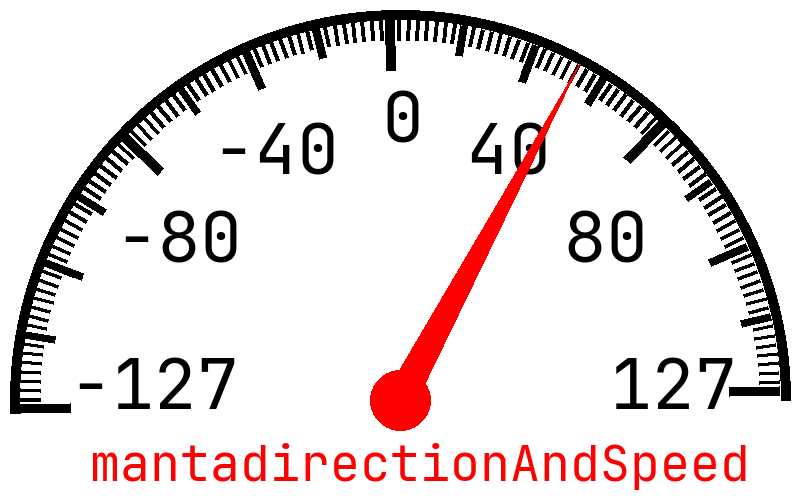

In [48]:
from math import cos, sin, radians

def draw_pixel_dial(current_value):
    width, height = 800, 800
    CENTRE = int(width/2)
    to_degree = lambda x: (360 * (x/256))

    def draw_dial(draw, val, end=380):
        val = val - 64
        angle = to_degree(val)
        cosang, sinang = cos(radians(angle)), sin(radians(angle))
        x_end = CENTRE + end * cosang
        y_end = CENTRE + end * sinang

        val = 256 - val
        angle = to_degree(val)
        cosang, sinang = cos(radians(angle)), sin(radians(angle))
        
        # Retrieve vertices of the line
        x1, y1 = CENTRE, CENTRE + 15
        x2, y2 = CENTRE, CENTRE - 15
        cx = (x2 - x1) / 2 + x1
        cy = (y2 - y1) / 2 + y1

        # Rotate each around whole polyline's center point
        tx1, ty1 = x1-cx, y1-cy
        p1x = ( tx1*cosang + ty1*sinang) + cx
        p1y = (-tx1*sinang + ty1*cosang) + cy
        tx2, ty2 = x2-cx, y2-cy
        p2x = ( tx2*cosang + ty2*sinang) + cx
        p2y = (-tx2*sinang + ty2*cosang) + cy

        draw.polygon([(p1x, p1y), (x_end,y_end), (p2x, p2y)], fill = "red")
        
    def draw_markings(draw, interval=32, start=0, end=0, width=3):
        for v in range(127, 256, interval):
            angle = to_degree(v)
            x_start = CENTRE + start * cos(radians(angle))
            y_start = CENTRE + start * sin(radians(angle))
            x_end = CENTRE + end * cos(radians(angle))
            y_end = CENTRE + end * sin(radians(angle))
            draw.line((x_start, y_start, x_end, y_end), fill="black", width=width)

    img = Image.new("RGBA", (width, height), color=(255, 255, 255))  # White background
    draw = ImageDraw.Draw(img)

    # Draw the outer circle
    draw.arc((10, 10, width-10, height-10), start=178, end=360, fill="black", width=10)

    # Draw markings
    draw_markings(draw, interval=32, start=330, end=380, width=10)
    draw_markings(draw, interval=16, start=340, end=380, width=8)
    draw_markings(draw, interval=8, start=350, end=380, width=8)
    draw_markings(draw, interval=1, start=360, end=380, width=4)

    label_fnt_size = 70
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)

    for v in [-127,-80,-40,0,40,80,127]:
        angle = to_degree(v)/2
        angle -= 90
        x_text = (CENTRE - 60) + 270 * cos(radians(angle))
        y_text = (CENTRE - 60) + 270 * sin(radians(angle))
        s = "\u202f\u202f0 " if v == 0 else str(v)
        draw.text((x_text, y_text), s, fill="black", font=label_fnt)

    label_fnt_size = 50
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    draw.text((CENTRE - 310, CENTRE+30), "mantadirectionAndSpeed", fill="red", font=label_fnt)

    # Draw the dial
    draw_dial(draw, 20)
    # Draw dial handle
    draw.ellipse((CENTRE-30, CENTRE-30, CENTRE+30, CENTRE+30), fill="red")

    return img
img = draw_pixel_dial(255).crop((0, 0, 800, 500))
img.save("scrolling/mantaDirectionAndSpeed.png")
img

### Draw Bit table for pixelX

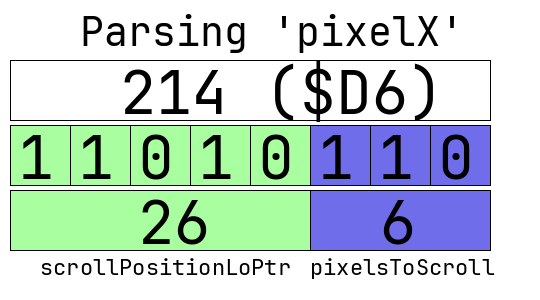

In [94]:
BASE_DIM = 60
CELL_WIDTH = BASE_DIM
CELL_HEIGHT = BASE_DIM
width = (CELL_WIDTH * 8) + BASE_DIM
height = (CELL_HEIGHT * 4) + BASE_DIM

num = 214
bit_value = ''.join(list(map(str, '{:08b}'.format(num))))

img = Image.new("RGBA", (width, height), color=(255, 255, 255))  # White background
draw = ImageDraw.Draw(img)

label_fnt_size = BASE_DIM - 20
label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
draw.text((80, 5), "Parsing 'pixelX'", fill="black", font=label_fnt)

X,Y = 10,60
label_fnt_size = BASE_DIM
label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
draw.rectangle((X, Y, X+(CELL_WIDTH*8), Y+CELL_HEIGHT), fill="#ffffff", outline="black")
v = f"{int(bit_value,2)} (${hex(num)[2:].upper()})"
draw.text((X+110, Y-8), v, fill="black", font=label_fnt)


X= 10
Y += CELL_HEIGHT + 5
label_fnt_size = BASE_DIM
label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
for i in range(0,5):
    draw.rectangle((X, Y, X+CELL_WIDTH, Y+CELL_HEIGHT), fill="#a9ff9f", outline="black")
    draw.text((X+8, Y-8), bit_value[i], fill="black", font=label_fnt)
    X += CELL_WIDTH
for i in range(5,8):
    draw.rectangle((X, Y, X+CELL_WIDTH, Y+CELL_HEIGHT), fill="#706deb", outline="black")
    draw.text((X+8, Y-8), bit_value[i], fill="black", font=label_fnt)
    X += CELL_WIDTH

Y += CELL_HEIGHT + 5
X = 10
draw.rectangle((X, Y, X+(CELL_WIDTH*5), Y+CELL_HEIGHT), fill="#a9ff9f", outline="black")
v = str(int(bit_value[:5],2))
X+=128
draw.text((X, Y-8), v, fill="black", font=label_fnt)

X = (CELL_WIDTH * 5) + 10
draw.rectangle((X, Y, X+(CELL_WIDTH*3), Y+CELL_HEIGHT), fill="#706deb", outline="black")
v = str(int(bit_value[5:],2))
draw.text((X+70, Y-8), v, fill="black", font=label_fnt)

Y += CELL_HEIGHT + 10
X = 100
label_fnt_size = BASE_DIM - 38
label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
draw.text((X-60, Y-8), "scrollPositionLoPtr", fill="black", font=label_fnt)

X = 310
label_fnt_size = BASE_DIM - 38
label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
draw.text((X, Y-8), "pixelsToScroll", fill="black", font=label_fnt)

img.save("scrolling/pixelX.png")
img


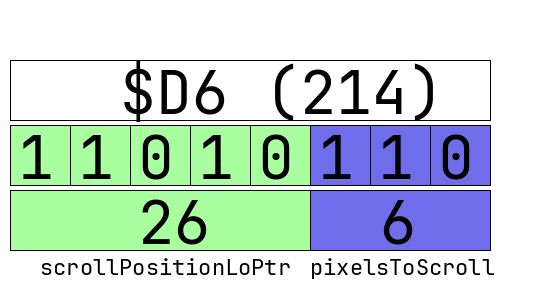

In [96]:
BASE_DIM = 60
CELL_WIDTH = BASE_DIM
CELL_HEIGHT = BASE_DIM
width = (CELL_WIDTH * 8) + BASE_DIM
height = (CELL_HEIGHT * 4) + BASE_DIM

num = 214
bit_value = ''.join(list(map(str, '{:08b}'.format(num))))

img = Image.new("RGBA", (width, height), color=(255, 255, 255))  # White background
draw = ImageDraw.Draw(img)

X,Y = 10,60
label_fnt_size = BASE_DIM
label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
draw.rectangle((X, Y, X+(CELL_WIDTH*8), Y+CELL_HEIGHT), fill="#ffffff", outline="black")
v = f"${hex(num)[2:].upper()} ({int(bit_value,2)})"
draw.text((X+110, Y-8), v, fill="black", font=label_fnt)


X= 10
Y += CELL_HEIGHT + 5
label_fnt_size = BASE_DIM
label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
for i in range(0,5):
    draw.rectangle((X, Y, X+CELL_WIDTH, Y+CELL_HEIGHT), fill="#a9ff9f", outline="black")
    draw.text((X+8, Y-8), bit_value[i], fill="black", font=label_fnt)
    X += CELL_WIDTH
for i in range(5,8):
    draw.rectangle((X, Y, X+CELL_WIDTH, Y+CELL_HEIGHT), fill="#706deb", outline="black")
    draw.text((X+8, Y-8), bit_value[i], fill="black", font=label_fnt)
    X += CELL_WIDTH

Y += CELL_HEIGHT + 5
X = 10
draw.rectangle((X, Y, X+(CELL_WIDTH*5), Y+CELL_HEIGHT), fill="#a9ff9f", outline="black")
v = str(int(bit_value[:5],2))
X+=128
draw.text((X, Y-8), v, fill="black", font=label_fnt)

X = (CELL_WIDTH * 5) + 10
draw.rectangle((X, Y, X+(CELL_WIDTH*3), Y+CELL_HEIGHT), fill="#706deb", outline="black")
v = str(int(bit_value[5:],2))
draw.text((X+70, Y-8), v, fill="black", font=label_fnt)

Y += CELL_HEIGHT + 10
X = 100
label_fnt_size = BASE_DIM - 38
label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
draw.text((X-60, Y-8), "scrollPositionLoPtr", fill="black", font=label_fnt)

X = 310
label_fnt_size = BASE_DIM - 38
label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
draw.text((X, Y-8), "pixelsToScroll", fill="black", font=label_fnt)

img.save("scrolling/pixelX.png")
img


In [90]:
hex(0x04 * 32)

'0x80'

In [84]:
hex(0x8260 + 27)

'0x827b'

In [82]:
for num in [214,0xDD,0xEE,0xF7,0x7B]:
    print(''.join(list(map(str, '{:08b}'.format(num)))), num, hex(num))

11010110 214 0xd6
11011101 221 0xdd
11101110 238 0xee
11110111 247 0xf7
01111011 123 0x7b


In [86]:
for num in [0x07,0x83,0xc1,0x60]:
    print(''.join(list(map(str, '{:08b}'.format(num)))), num, hex(num))

00000111 7 0x7
10000011 131 0x83
11000001 193 0xc1
01100000 96 0x60


### Progressive draw of screen

In [148]:
from PIL import Image, ImageDraw, ImageColor, ImageFont
def generateScreenDiagramWithGrid(level_name, level_number, level_image, description, X_START, X_END, Y_START=0x82, Y_END=0xA4):
    img_width = (X_END - X_START) * 8 * 15
    img_height = int((Y_END - Y_START) / 2) * 8 * 15
    img = Image.new('RGBA', (150 + img_width + 50, 230 + img_height + 20))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Grid Literals - Rows
    grid_literals = []
    for n in range(Y_START, Y_END, 2):
        grid_literals += [hex(n)[2:].upper()]
    label_text = '\n'.join(grid_literals)
    label_fnt_size = 113
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_height = len(label_text) * label_fnt_size
    txt_width =  (label_fnt_size + 25)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="gray")
    label = txt
    img.paste(label, (10,160),mask=label)

    # Grid Literals - Cols
    grid_literals = []
    for n in range(X_START, X_END, 1):
        grid_literals += [hex(n)[2:].upper()]
    label_fnt_size = 113
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    x = 150
    for label_text in grid_literals:
        txt_height = (label_fnt_size + 25)
        txt_width =  len(label_text) * label_fnt_size
        txt = Image.new('RGBA', (txt_width, txt_height))
        draw = ImageDraw.Draw(txt)
        draw.rectangle([(0,0), txt.size], fill = "white")
        draw.text((0, 0), label_text, font=label_fnt, fill="gray")
        label = txt.rotate(90,expand=1)
        img.paste(label,(x, -60),mask=label)
        x += 120

    # Main Sprite image
    img.paste(level_image, (170,180),mask=level_image)

    return img


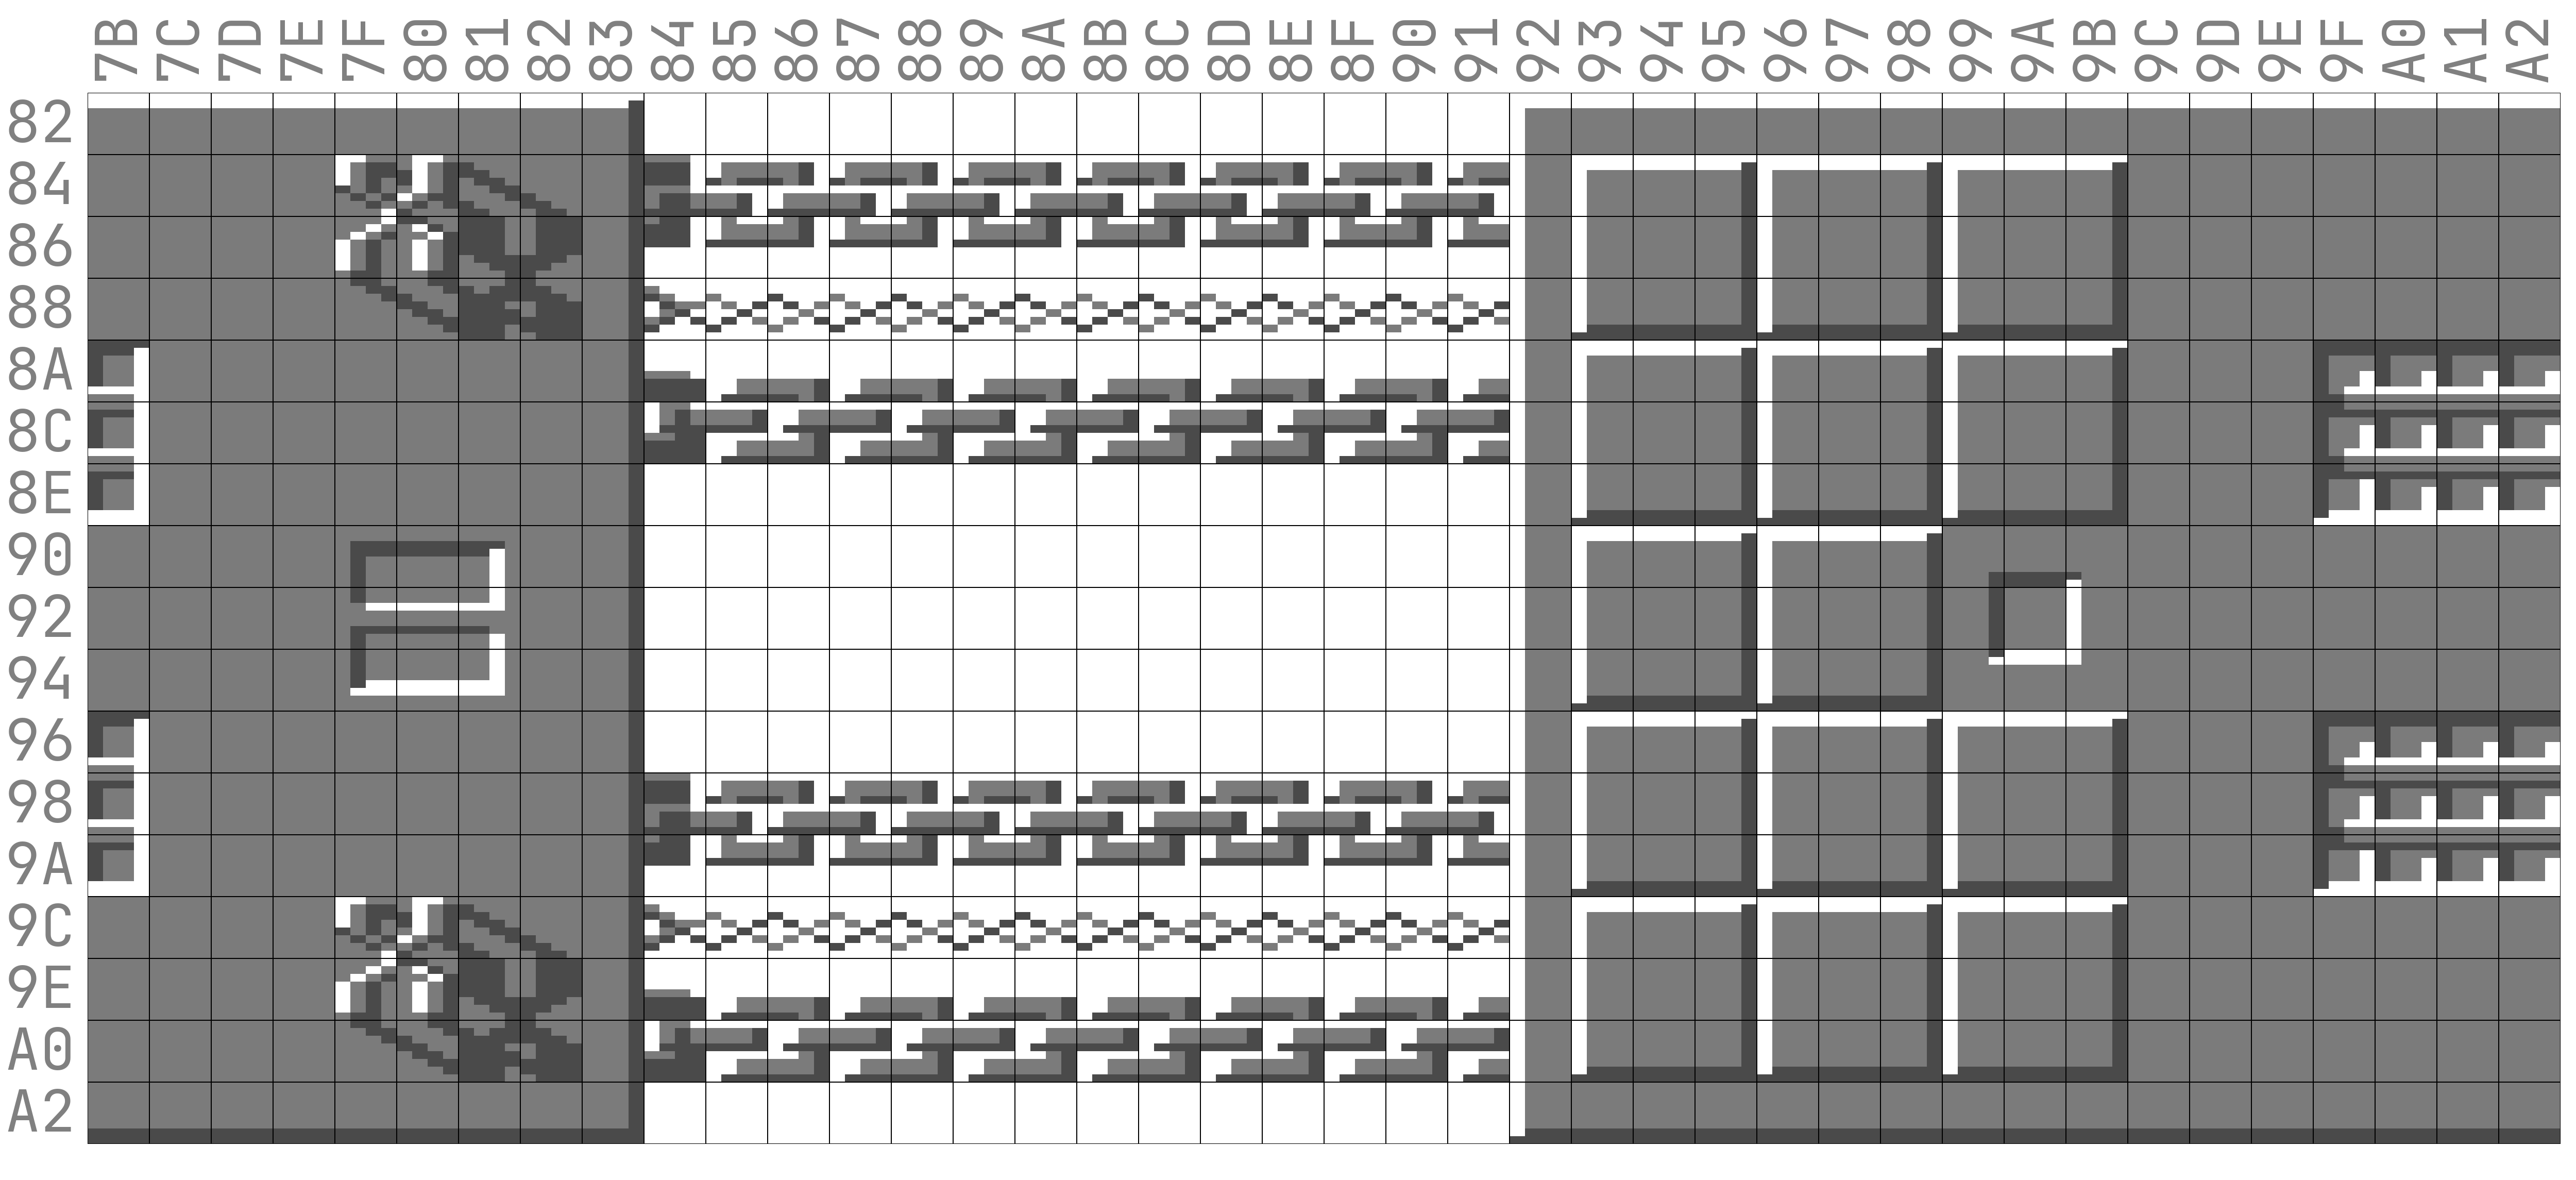

In [151]:
from PIL import Image
half_width = 11040
LEVEL = 10
SEGMENT = 3
X_OFFSET = 27
X_END =   (0x20 * SEGMENT) + X_OFFSET + 40

X_START = (0x20 * SEGMENT) + X_OFFSET
cols = 40
for rows in range(1, 18):
    crop_start = X_START * 8 * 15
    crop_end = crop_start + (cols * 8 * 15)
    crop_height = rows * 8 * 15
    img = Image.open(f"scrolling/surface_diagrams/{LEVEL}_no_text.png")
    img1 = img.crop((crop_start, 0, crop_end, crop_height))
    Y_START = 0x82
    Y_END = Y_START + (rows * 2)
    img1 = generateScreenDiagramWithGrid("QUADMIUM", LEVEL, img1, f"SCROLL/SEGMENT/{str(SEGMENT).zfill(2)}", X_START, X_END, Y_START, Y_END)
    img1.save(f"scrolling/drawing/{LEVEL}_diagram_{SEGMENT}_{rows}_{cols}_diagram.png")
img1